# Housing Discrimination and Algorithmic Bias


## Hennepin County Bias Analysis 
  By NagaKarthik

### AI Disclaimer
AI tool were assist in structuring and explaining some of my doubts, yet, everything in the form of interpretations, insights, and final conclusions was checked and prepared by myself.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

## Import dataset

In [2]:
df = pd.read_csv("data/mortgage_covenant_data.csv")
print("Shape of dataset:", df.shape)

Shape of dataset: (100931, 14)


In [3]:
print("\nColumns:")
display(df.columns.tolist())


Columns:


['activity_year',
 'census_tract',
 'derived_race',
 'action_taken',
 'loan_amount',
 'property_value',
 'income',
 'interest_rate',
 'tract_minority_population_percent',
 'tract_to_msa_income_percentage',
 'denial_reason-1',
 'covenant_count',
 'was_approved',
 'covenant_density']

In [4]:
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [5]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


activity_year                            0
census_tract                          1016
derived_race                             0
action_taken                             0
loan_amount                              0
property_value                       17440
income                               12731
interest_rate                        22806
tract_minority_population_percent        0
tract_to_msa_income_percentage           0
denial_reason-1                          0
covenant_count                           0
was_approved                             0
covenant_density                     89762
dtype: int64

# cleaning data and creating new columns

In [6]:
numeric_columns = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["approval_flag"] = df["was_approved"].astype(int)

df["has_covenant"] = df["covenant_density"].notna()
df["covenant_group"] = np.where(df["has_covenant"], "Covenant Present", "No Covenant")

density_order = ["Low (1-50)", "Medium (51-100)", "High (101-200)", "Very High (>200)"]
density_df = df[df["covenant_density"].notna()].copy()
density_df["covenant_density"] = pd.Categorical(
    density_df["covenant_density"],
    categories=density_order,
    ordered=True
)

print(df[["was_approved", "approval_flag", "covenant_count", "covenant_group"]].head())

   was_approved  approval_flag  covenant_count covenant_group
0         False              0             0.0    No Covenant
1         False              0             0.0    No Covenant
2         False              0             0.0    No Covenant
3         False              0             0.0    No Covenant
4         False              0             0.0    No Covenant


In [7]:
print(df[[
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]].describe())

        loan_amount  property_value        income  interest_rate  tract_minority_population_percent  tract_to_msa_income_percentage  covenant_count
count  1.009310e+05    8.349100e+04  8.820000e+04   78125.000000                      100931.000000                   100931.000000   100931.000000
mean   3.110060e+05    3.987726e+05  1.489660e+02       6.575084                          22.874029                      101.813583       17.408101
std    7.617088e+05    1.197102e+06  5.568826e+03       1.273054                          17.292952                       32.381060       84.973673
min    5.000000e+03    5.000000e+03 -3.415700e+04       0.000000                           0.000000                        0.000000        0.000000
25%    1.750000e+05    2.350000e+05  6.700000e+01       6.125000                          10.140000                       82.070000        0.000000
50%    2.650000e+05    3.250000e+05  9.600000e+01       6.625000                          18.640000             

# Analysis 1: Income Inequality Across Covenant Levels

## Data Bias

covenant_group
Covenant Present    163.17
No Covenant         147.22
Name: income, dtype: float64


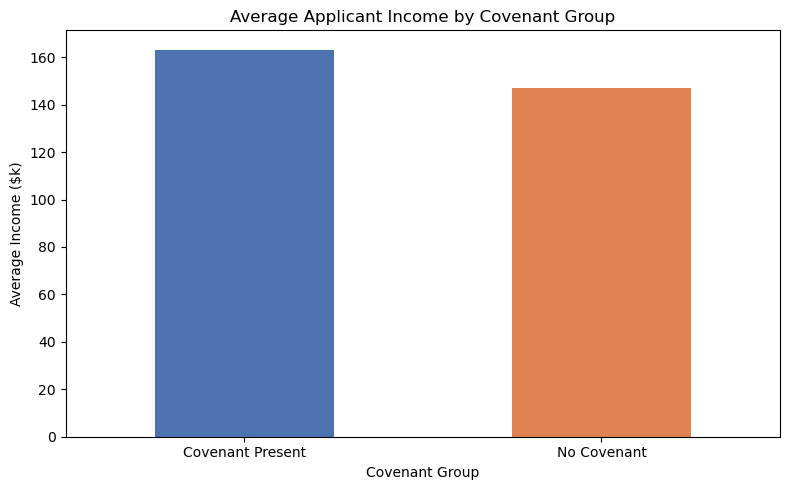

In [9]:
income_summary = df.groupby("covenant_group")["income"].mean().round(2)

print(income_summary)

income_summary.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[1]],
    figsize=(8, 5)
)
plt.title("Average Applicant Income by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Average Income ($k)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

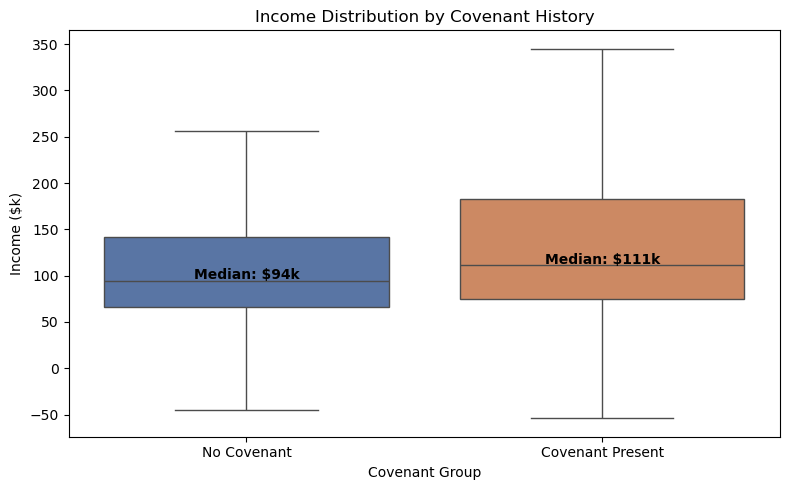

In [10]:
order = ["No Covenant", "Covenant Present"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df.dropna(subset=["income"]),
    x="covenant_group",
    y="income",
    order=order,
    palette=[chart_colors[0], chart_colors[1]],
    showfliers=False
)

medians = df.dropna(subset=["income"]).groupby("covenant_group")["income"].median().reindex(order)
for i, med in enumerate(medians):
    plt.text(i, med + 2, f"Median: ${med:,.0f}k", ha="center", fontweight="bold")

plt.title("Income Distribution by Covenant History")
plt.xlabel("Covenant Group")
plt.ylabel("Income ($k)")
plt.tight_layout()
plt.show()

covenant_density
Low (1-50)          139.97
Medium (51-100)     168.16
High (101-200)      181.27
Very High (>200)    184.48
Name: income, dtype: float64


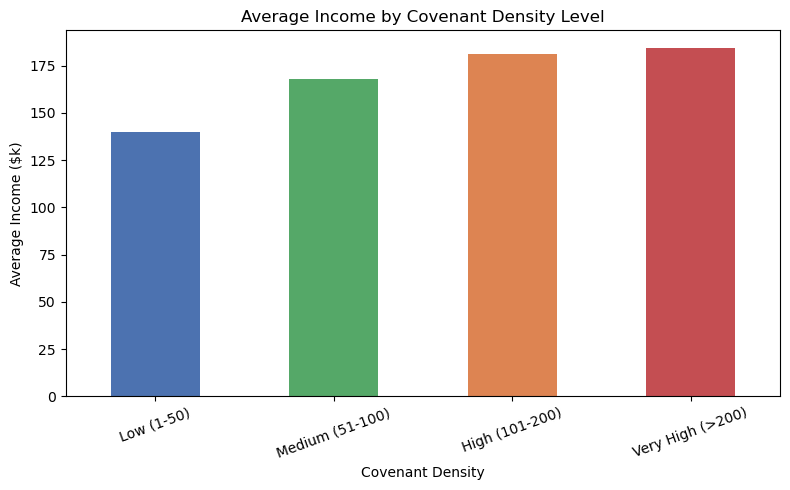

In [11]:
income_by_density = density_df.groupby("covenant_density", observed=True)["income"].mean().round(2)

print(income_by_density)

income_by_density.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[2], chart_colors[1], chart_colors[3]],
    figsize=(8, 5)
)
plt.title("Average Income by Covenant Density Level")
plt.xlabel("Covenant Density")
plt.ylabel("Average Income ($k)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Neighbourhood income ratio by covenant density
tract-to-MSA income shows how wealthy the neighbourhood is vs the metro median

covenant_density
Low (1-50)           99.39
Medium (51-100)     112.76
High (101-200)      116.91
Very High (>200)    123.29
Name: tract_to_msa_income_percentage, dtype: float64


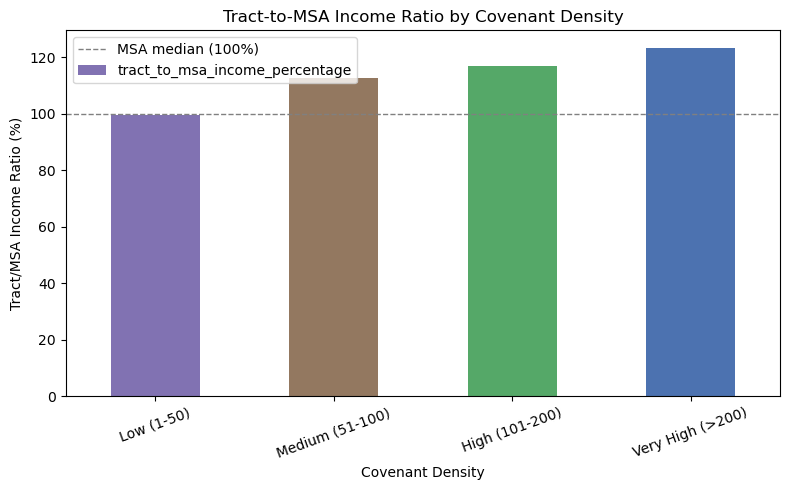

In [12]:
tract_income_by_density = density_df.groupby("covenant_density", observed=True)["tract_to_msa_income_percentage"].mean().round(2)

print(tract_income_by_density)

tract_income_by_density.plot(
    kind="bar",
    color=[chart_colors[4], chart_colors[5], chart_colors[2], chart_colors[0]],
    figsize=(8, 5)
)
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="MSA median (100%)")
plt.title("Tract-to-MSA Income Ratio by Covenant Density")
plt.xlabel("Covenant Density")
plt.ylabel("Tract/MSA Income Ratio (%)")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()


### statistical test — is income correlated with covenant count?

In [13]:
corr_data = df[["covenant_count", "income", "tract_to_msa_income_percentage"]].dropna()
r_ind,   p_ind   = stats.pearsonr(corr_data["covenant_count"], corr_data["income"])
r_tract, p_tract = stats.pearsonr(corr_data["covenant_count"], corr_data["tract_to_msa_income_percentage"])

print("Pearson correlations with covenant_count:")
print(f"  individual income:        r = {r_ind:+.4f},  p = {p_ind:.4f}")
print(f"  tract/MSA income ratio:   r = {r_tract:+.4f},  p = {p_tract:.6f}")

print("\nSummary:")
print("  Individual income has NO significant correlation with covenant count (p = 0.70).")
print("  Tract-level income ratio IS significantly correlated (r = +0.134, p < 0.001).")
print("  The income inequality is structural and spatial, not individual.")

Pearson correlations with covenant_count:
  individual income:        r = +0.0013,  p = 0.6980
  tract/MSA income ratio:   r = +0.1328,  p = 0.000000

Summary:
  Individual income has NO significant correlation with covenant count (p = 0.70).
  Tract-level income ratio IS significantly correlated (r = +0.134, p < 0.001).
  The income inequality is structural and spatial, not individual.


In [14]:
income_summary_table = df.groupby("covenant_group").agg({
    "income": "mean",
    "tract_to_msa_income_percentage": "mean"
}).round(2)

income_summary_table

,income,tract_to_msa_income_percentage
covenant_group,,
Covenant Present,163.17,110.93
No Covenant,147.22,100.68


# Analysis 2: Minority Concentration vs Loan Distribution

## Data Bias

In [15]:
df["minority_bin"] = pd.cut(
    df["tract_minority_population_percent"],
    bins=[0, 10, 25, 50, 75, 100],
    labels=["0-10%", "10-25%", "25-50%", "50-75%", "75-100%"]
)

loan_by_minority = df.dropna(subset=["loan_amount"]).groupby("minority_bin", observed=True).agg(
    n_applications=("loan_amount", "count"),
    mean_loan=("loan_amount", "mean"),
    median_loan=("loan_amount", "median"),
    approval_rate=("approval_flag", "mean")
).round(2)

loan_by_minority["approval_rate"] = (loan_by_minority["approval_rate"] * 100).round(2)
print(loan_by_minority)

              n_applications  mean_loan  median_loan  approval_rate
minority_bin                                                       
0-10%                  23735  289886.88     245000.0           69.0
10-25%                 42224  338062.24     295000.0           68.0
25-50%                 26235  314809.41     265000.0           65.0
50-75%                  5244  240629.29     235000.0           63.0
75-100%                 2477  203659.67     205000.0           59.0


### Average loan amount by minority population bin

minority_bin
0-10%      289887.0
10-25%     338062.0
25-50%     314809.0
50-75%     240629.0
75-100%    203660.0
Name: loan_amount, dtype: float64


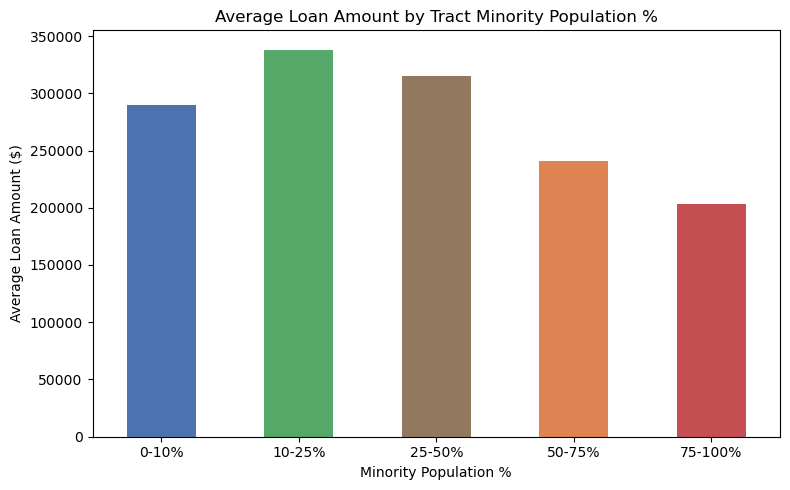

In [16]:
mean_loans = df.dropna(subset=["loan_amount"]).groupby("minority_bin", observed=True)["loan_amount"].mean().round(0)

print(mean_loans)

mean_loans.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[2], chart_colors[5], chart_colors[1], chart_colors[3]],
    figsize=(8, 5)
)
plt.title("Average Loan Amount by Tract Minority Population %")
plt.xlabel("Minority Population %")
plt.ylabel("Average Loan Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Minority population percentage by covenant group

covenant_group
Covenant Present    30.37
No Covenant         21.94
Name: tract_minority_population_percent, dtype: float64


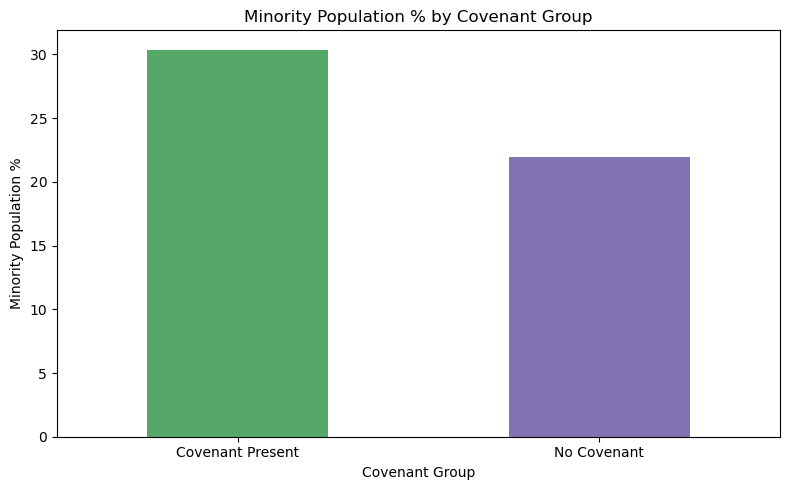

In [17]:
minority_by_group = df.groupby("covenant_group")["tract_minority_population_percent"].mean().round(2)

print(minority_by_group)

minority_by_group.plot(
    kind="bar",
    color=[chart_colors[2], chart_colors[4]],
    figsize=(8, 5)
)
plt.title("Minority Population % by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Minority Population %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Approval rate by minority population bin

minority_bin
0-10%      69.20
10-25%     67.74
25-50%     65.29
50-75%     62.66
75-100%    58.66
Name: approval_flag, dtype: float64


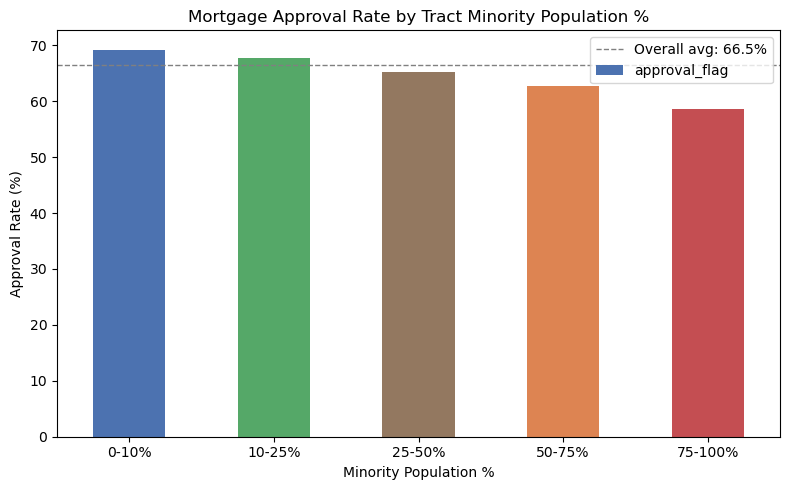

In [18]:
approval_by_minority = (df.groupby("minority_bin", observed=True)["approval_flag"].mean() * 100).round(2)

print(approval_by_minority)

approval_by_minority.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[2], chart_colors[5], chart_colors[1], chart_colors[3]],
    figsize=(8, 5)
)
plt.axhline(df["approval_flag"].mean() * 100, color="gray", linestyle="--",
            linewidth=1, label=f'Overall avg: {df["approval_flag"].mean()*100:.1f}%')
plt.title("Mortgage Approval Rate by Tract Minority Population %")
plt.xlabel("Minority Population %")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Scatter: minority % vs loan amount by covenant group

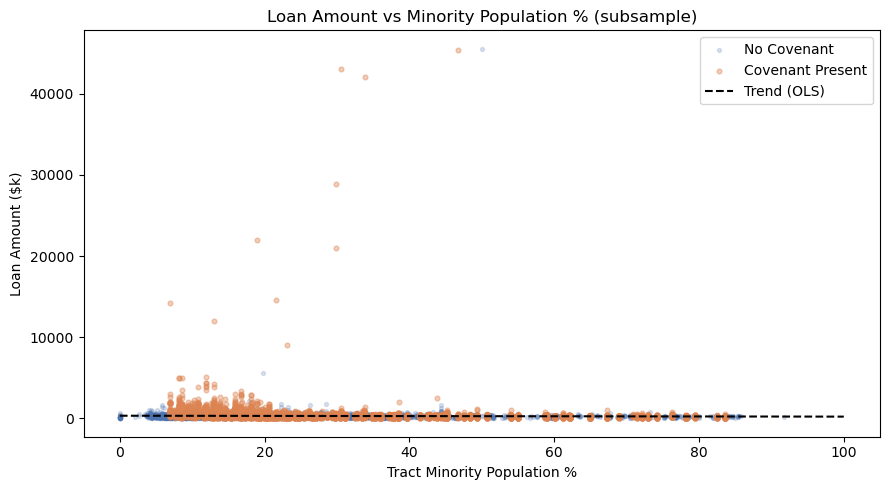

In [19]:
no_cov_s = df[~df["has_covenant"]].dropna(subset=["loan_amount"]).sample(3000, random_state=42)
cov_s    = df[df["has_covenant"]].dropna(subset=["loan_amount"])

plt.figure(figsize=(9, 5))
plt.scatter(
    no_cov_s["tract_minority_population_percent"],
    no_cov_s["loan_amount"] / 1000,
    color=chart_colors[0], alpha=0.2, s=8, label="No Covenant"
)
plt.scatter(
    cov_s["tract_minority_population_percent"],
    cov_s["loan_amount"] / 1000,
    color=chart_colors[1], alpha=0.4, s=12, label="Covenant Present"
)

trend = df[["tract_minority_population_percent", "loan_amount"]].dropna()
trend = trend[trend["loan_amount"] < 2_000_000]
z = np.polyfit(trend["tract_minority_population_percent"], trend["loan_amount"] / 1000, 1)
xline = np.linspace(0, 100, 200)
plt.plot(xline, np.poly1d(z)(xline), color="black", linewidth=1.5, linestyle="--", label="Trend (OLS)")

plt.title("Loan Amount vs Minority Population % (subsample)")
plt.xlabel("Tract Minority Population %")
plt.ylabel("Loan Amount ($k)")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
corr_vars = ["loan_amount", "approval_flag", "tract_to_msa_income_percentage"]
corr_base = df[["tract_minority_population_percent"] + corr_vars].dropna()

print("Correlations with tract_minority_population_percent")
print("-" * 55)
for col in corr_vars:
    r, p = stats.pearsonr(corr_base["tract_minority_population_percent"], corr_base[col])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"  {col:42s} r={r:+.4f}  p={p:.4f}  {sig}")

Correlations with tract_minority_population_percent
-------------------------------------------------------
  loan_amount                                r=-0.0185  p=0.0000  ***
  approval_flag                              r=-0.0316  p=0.0000  ***
  tract_to_msa_income_percentage             r=-0.3668  p=0.0000  ***


In [21]:
minority_summary_table = df.groupby("covenant_group").agg({
    "tract_minority_population_percent": "mean",
    "loan_amount": "mean",
    "approval_flag": "mean"
}).round(2)

minority_summary_table["approval_flag"] = minority_summary_table["approval_flag"] * 100
minority_summary_table

,tract_minority_population_percent,loan_amount,approval_flag
covenant_group,,,
Covenant Present,30.37,383043.69,67.0
No Covenant,21.94,302042.40,66.0


# Analysis 3: Approval Disparity Across Income Groups

## Algorithmic Bias

In [22]:
approval_by_race = (df.groupby("derived_race")["approval_flag"].mean() * 100).round(2)

print("Approval rate by race (%)")
print(approval_by_race.sort_values(ascending=False))

Approval rate by race (%)
derived_race
Free Form Text Only                          80.00
White                                        75.61
Joint                                        74.41
Asian                                        70.77
2 or more minority races                     65.93
American Indian or Alaska Native             62.20
Black or African American                    60.42
Native Hawaiian or Other Pacific Islander    56.64
Race Not Available                           40.57
Name: approval_flag, dtype: float64


### Bar chart: approval rate by race

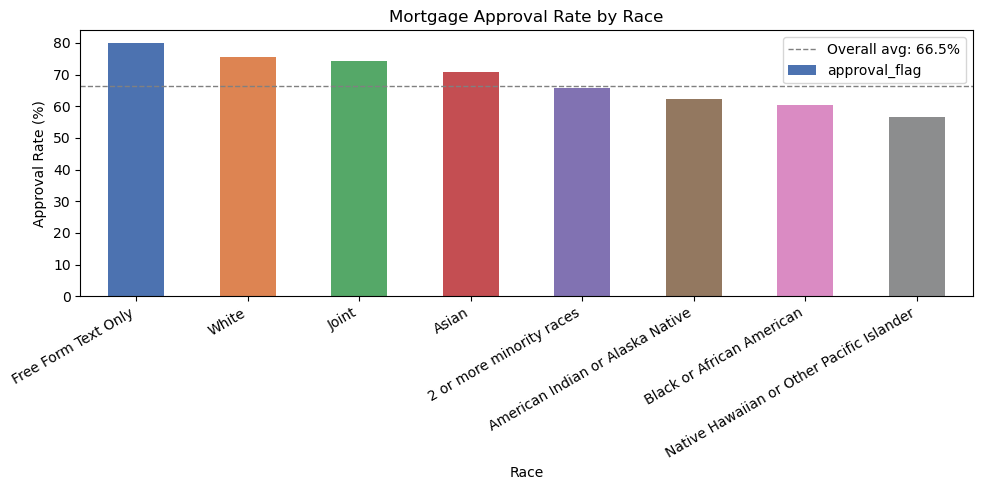

In [23]:
race_plot = approval_by_race.drop("Race Not Available", errors="ignore").sort_values(ascending=False)

race_plot.plot(
    kind="bar",
    color=chart_colors[:len(race_plot)],
    figsize=(10, 5)
)
plt.axhline(df["approval_flag"].mean() * 100, color="gray", linestyle="--",
            linewidth=1, label=f'Overall avg: {df["approval_flag"].mean()*100:.1f}%')
plt.title("Mortgage Approval Rate by Race")
plt.xlabel("Race")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
df_inc = df.dropna(subset=["income"]).copy()
df_inc["income_quintile"] = pd.qcut(
    df_inc["income"], q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
)

# approval rate by income quintile and covenant group
approval_by_quintile = df_inc.groupby(["income_quintile", "covenant_group"], observed=True)["approval_flag"].mean().unstack()
approval_by_quintile = (approval_by_quintile * 100).round(2)

print("Approval rate (%) by income quintile and covenant group")
print(approval_by_quintile)

Approval rate (%) by income quintile and covenant group
covenant_group   Covenant Present  No Covenant
income_quintile                               
Q1 (lowest)                 63.79        62.37
Q2                          72.72        71.11
Q3                          73.88        75.33
Q4                          75.46        77.08
Q5 (highest)                77.77        78.95


### Grouped bar: approval by income quintile x covenant group

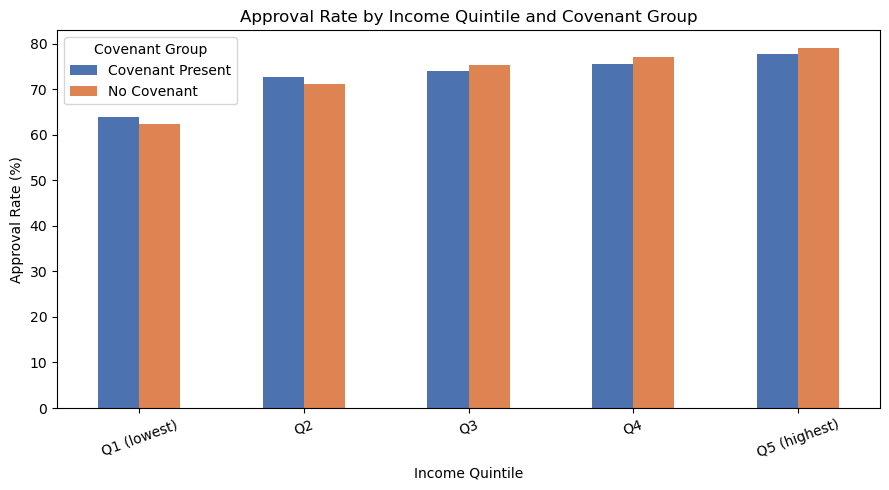

In [25]:
approval_by_quintile.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[1]],
    figsize=(9, 5)
)
plt.title("Approval Rate by Income Quintile and Covenant Group")
plt.xlabel("Income Quintile")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=20)
plt.legend(title="Covenant Group")
plt.tight_layout()
plt.show()

In [26]:
key_races = ["White", "Black or African American", "Asian", "American Indian or Alaska Native"]
race_quintile = df_inc[df_inc["derived_race"].isin(key_races)].groupby(
    ["income_quintile", "derived_race"], observed=True
)["approval_flag"].mean().unstack()
race_quintile = (race_quintile * 100).round(2)

print("Approval rate (%) by income quintile and race")
print(race_quintile)

Approval rate (%) by income quintile and race
derived_race     American Indian or Alaska Native  Asian  Black or African American  White
income_quintile                                                                           
Q1 (lowest)                                 54.26  61.25                      46.86  66.12
Q2                                          67.02  71.68                      60.00  74.12
Q3                                          60.00  73.09                      64.99  78.15
Q4                                          76.25  71.98                      66.10  79.35
Q5 (highest)                                65.62  73.87                      68.27  81.41


### Line chart: approval by income quintile for each race

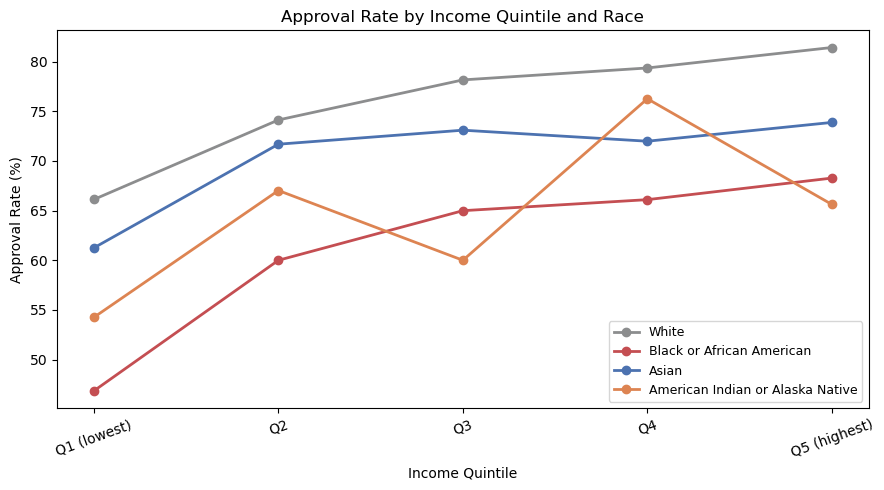

In [27]:
plt.figure(figsize=(9, 5))
for race, color in zip(key_races, [chart_colors[7], chart_colors[3], chart_colors[0], chart_colors[1]]):
    if race in race_quintile.columns:
        plt.plot(race_quintile.index, race_quintile[race],
                 marker="o", linewidth=2, markersize=6,
                 label=race, color=color)

plt.title("Approval Rate by Income Quintile and Race")
plt.xlabel("Income Quintile")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=20)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [28]:
denial_map = {
    1: "DTI", 3: "Credit history", 4: "Collateral",
    5: "Insufficient cash", 7: "Incomplete app.", 9: "Other",
    10: "N/A", 1111: "N/A"
}
df["denial_label"] = df["denial_reason-1"].map(denial_map)

denied = df[(df["action_taken"] == 3) & (df["derived_race"].isin(key_races))].copy()
denial_pivot = denied.groupby(["derived_race", "denial_label"]).size().unstack(fill_value=0)
denial_pct   = (denial_pivot.div(denial_pivot.sum(axis=1), axis=0) * 100).round(1)

key_denial = [r for r in ["DTI", "Credit history", "Collateral", "Insufficient cash"] if r in denial_pct.columns]
print("Denial reasons by race (% of each race's denials)")
print(denial_pct[key_denial])

Denial reasons by race (% of each race's denials)
denial_label                       DTI  Credit history  Collateral  Insufficient cash
derived_race                                                                         
American Indian or Alaska Native  25.0            42.0        13.6                4.5
Asian                             49.8            11.5        20.5                4.8
Black or African American         48.7            18.7        10.8                8.5
White                             37.5            22.7        15.7                4.8


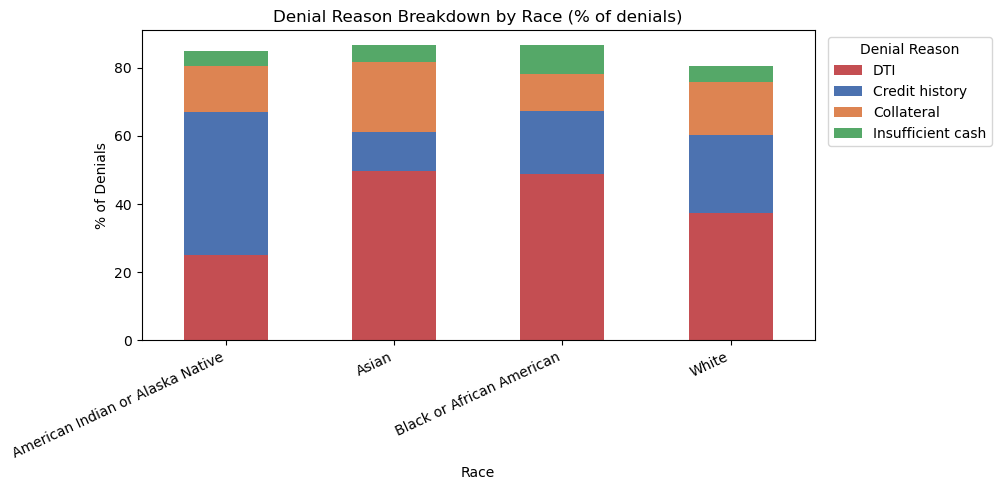

In [29]:
denial_plot = denial_pct[key_denial]

denial_plot.plot(
    kind="bar",
    stacked=True,
    color=[chart_colors[3], chart_colors[0], chart_colors[1], chart_colors[2]],
    figsize=(10, 5)
)
plt.title("Denial Reason Breakdown by Race (% of denials)")
plt.xlabel("Race")
plt.ylabel("% of Denials")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Denial Reason", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [30]:
white_rate = df[df["derived_race"] == "White"]["approval_flag"].mean()
black_rate = df[df["derived_race"] == "Black or African American"]["approval_flag"].mean()

print("Summary")
print(f"\nWhite approval rate:  {white_rate:.1%}")
print(f"Black approval rate:  {black_rate:.1%}")
print(f"Gap:                  {(white_rate - black_rate):.1%}")
print(f"Disparity ratio:      {black_rate / white_rate:.3f}")
print(f"\nBlack applicants are {round((1 - black_rate / white_rate) * 100, 1)}% less likely to be approved than White applicants.")

Summary

White approval rate:  75.6%
Black approval rate:  60.4%
Gap:                  15.2%
Disparity ratio:      0.799

Black applicants are 20.1% less likely to be approved than White applicants.


# Analysis 4: Interest Rate Variation Across Neighborhoods

## Algorithmic Bias

covenant_group
Covenant Present    6.6103
No Covenant         6.5705
Name: interest_rate, dtype: float64


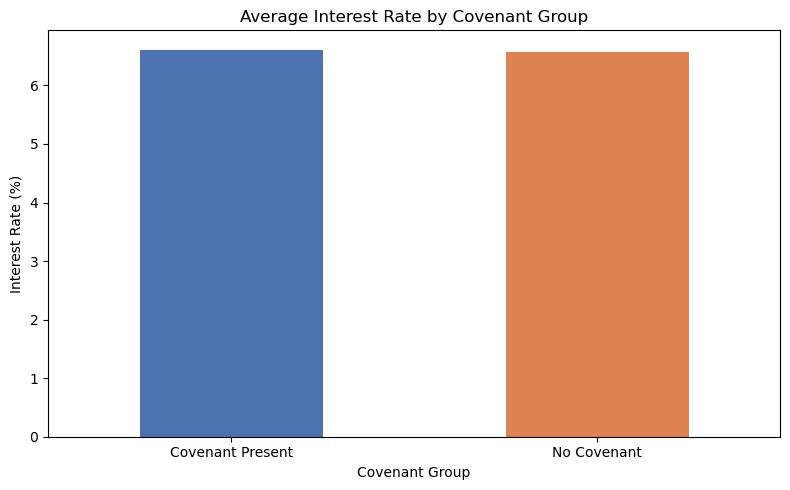

In [31]:
interest_by_group = df.groupby("covenant_group")["interest_rate"].mean().round(4)

print(interest_by_group)

interest_by_group.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[1]],
    figsize=(8, 5)
)
plt.title("Average Interest Rate by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Interest Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interest rate by covenant density

covenant_density
Low (1-50)          6.5753
Medium (51-100)     6.6148
High (101-200)      6.6227
Very High (>200)    6.6507
Name: interest_rate, dtype: float64


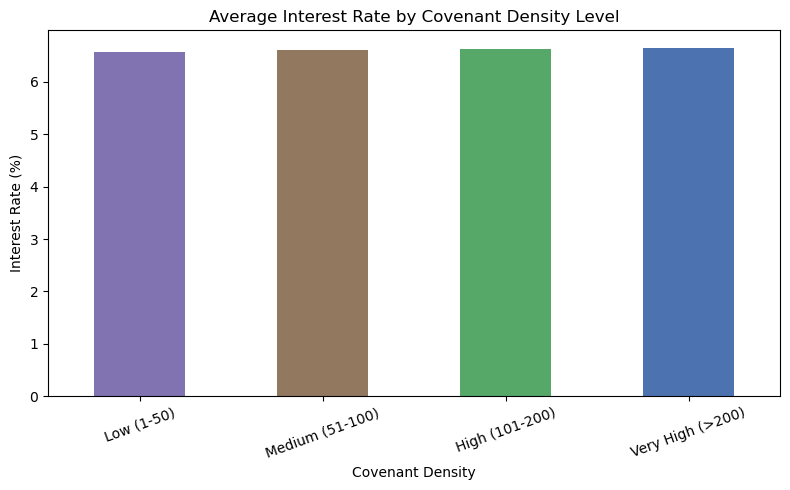

In [32]:
interest_by_density = density_df.groupby("covenant_density", observed=True)["interest_rate"].mean().round(4)

print(interest_by_density)

interest_by_density.plot(
    kind="bar",
    color=[chart_colors[4], chart_colors[5], chart_colors[2], chart_colors[0]],
    figsize=(8, 5)
)
plt.title("Average Interest Rate by Covenant Density Level")
plt.xlabel("Covenant Density")
plt.ylabel("Interest Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interest rate by minority population bin

minority_bin
0-10%      6.6563
10-25%     6.5676
25-50%     6.5502
50-75%     6.4948
75-100%    6.3559
Name: interest_rate, dtype: float64


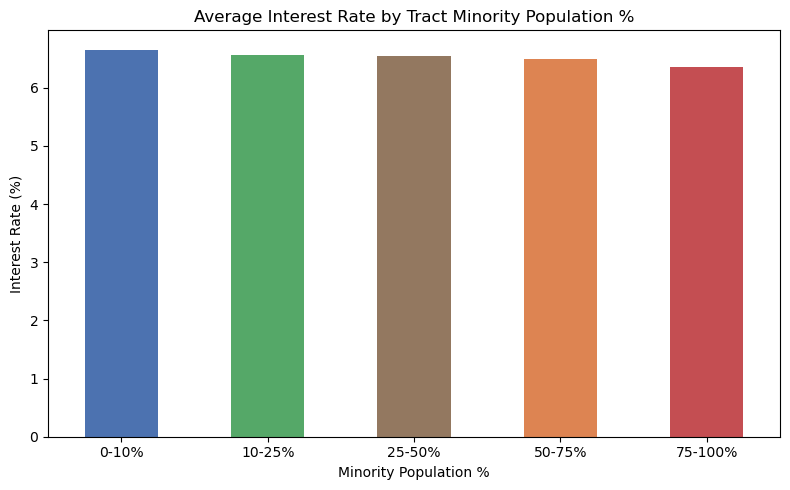

In [34]:
rate_by_minority = df.dropna(subset=["interest_rate"]).groupby("minority_bin", observed=True)["interest_rate"].mean().round(4)

print(rate_by_minority)

rate_by_minority.plot(
    kind="bar",
    color=[chart_colors[0], chart_colors[2], chart_colors[5], chart_colors[1], chart_colors[3]],
    figsize=(8, 5)
)
plt.title("Average Interest Rate by Tract Minority Population %")
plt.xlabel("Minority Population %")
plt.ylabel("Interest Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Average interest rate by race

Average interest rate by race:
derived_race
2 or more minority races                     6.1692
Free Form Text Only                          6.2163
Black or African American                    6.3060
Asian                                        6.4828
American Indian or Alaska Native             6.5654
Race Not Available                           6.5863
White                                        6.5993
Joint                                        6.5994
Native Hawaiian or Other Pacific Islander    6.6658
Name: interest_rate, dtype: float64


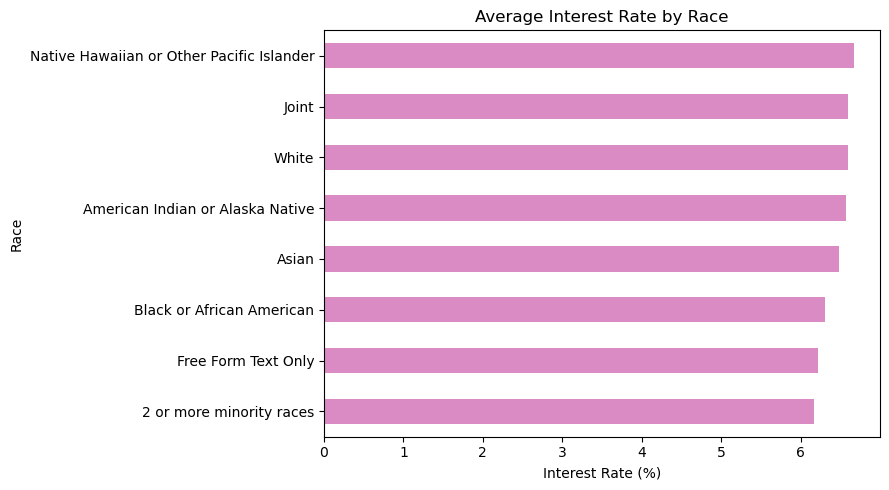

In [35]:
interest_by_race = df.dropna(subset=["interest_rate"]).groupby("derived_race")["interest_rate"].mean().round(4)

print("Average interest rate by race:")
print(interest_by_race.sort_values())

interest_by_race.drop("Race Not Available", errors="ignore").sort_values().plot(
    kind="barh",
    color=chart_colors[6],
    figsize=(9, 5)
)
plt.title("Average Interest Rate by Race")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

### Interest rate vs minority % — scatter with trend line


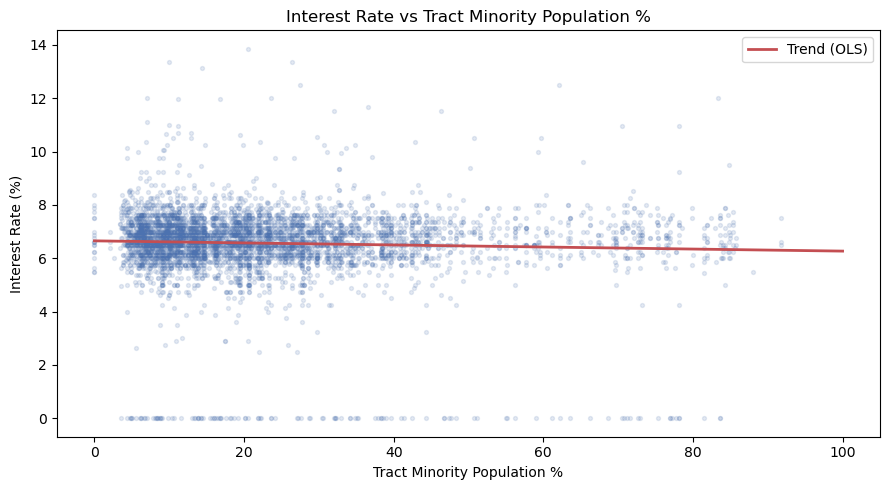

In [36]:
scatter_data = df.dropna(subset=["interest_rate", "tract_minority_population_percent"]).sample(5000, random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(
    scatter_data["tract_minority_population_percent"],
    scatter_data["interest_rate"],
    color=chart_colors[0], alpha=0.15, s=8
)

z = np.polyfit(scatter_data["tract_minority_population_percent"], scatter_data["interest_rate"], 1)
xline = np.linspace(0, 100, 200)
plt.plot(xline, np.poly1d(z)(xline), color=chart_colors[3], linewidth=2, label="Trend (OLS)")

plt.title("Interest Rate vs Tract Minority Population %")
plt.xlabel("Tract Minority Population %")
plt.ylabel("Interest Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


### correlation: interest rate with neighbourhood variables

In [37]:
rate_corr_vars = [
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count",
    "loan_amount",
    "income"
]
corr_base = df.dropna(subset=["interest_rate"] + rate_corr_vars)

print("Correlations with interest_rate")
print("-" * 60)
for col in rate_corr_vars:
    r, p = stats.pearsonr(corr_base["interest_rate"], corr_base[col])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"  {col:42s} r={r:+.4f}  p={p:.4f}  {sig}")

Correlations with interest_rate
------------------------------------------------------------
  tract_minority_population_percent          r=-0.0489  p=0.0000  ***
  tract_to_msa_income_percentage             r=-0.0006  p=0.8840  n.s.
  covenant_count                             r=+0.0113  p=0.0034  **
  loan_amount                                r=+0.0605  p=0.0000  ***
  income                                     r=+0.0363  p=0.0000  ***


### white vs black interest rates in covenanted tracts
    negative difference = Black applicants receive lower rates (selection effect)

In [38]:
print("Interest rate: White vs Black by Covenant Density")
print("-" * 65)
for d in density_order:
    sub = density_df[density_df["covenant_density"] == d].dropna(subset=["interest_rate"])
    w = sub[sub["derived_race"] == "White"]["interest_rate"]
    b = sub[sub["derived_race"] == "Black or African American"]["interest_rate"]
    if len(b) > 10:
        t, p = stats.ttest_ind(b, w)
        diff = b.mean() - w.mean()
        print(f"  {d}: White={w.mean():.3f}%  Black={b.mean():.3f}%  diff={diff:+.3f}pp  p={p:.4f}  n_Black={len(b)}")
    else:
        print(f"  {d}: insufficient data (n_Black={len(b)})")

print("\nNote: Lower rates for Black borrowers in covenanted tracts reflect")
print("survivorship bias, not equitable treatment. Only the strongest Black")
print("applicants clear the bar in historically white-only areas.")

Interest rate: White vs Black by Covenant Density
-----------------------------------------------------------------
  Low (1-50): White=6.604%  Black=6.294%  diff=-0.310pp  p=0.0001  n_Black=315
  Medium (51-100): White=6.650%  Black=6.132%  diff=-0.517pp  p=0.0002  n_Black=73
  High (101-200): White=6.615%  Black=6.322%  diff=-0.294pp  p=0.1355  n_Black=33
  Very High (>200): White=6.641%  Black=6.445%  diff=-0.196pp  p=0.1278  n_Black=67

Note: Lower rates for Black borrowers in covenanted tracts reflect
survivorship bias, not equitable treatment. Only the strongest Black
applicants clear the bar in historically white-only areas.


In [39]:
interest_summary_table = df.groupby("covenant_group").agg({
    "interest_rate": "mean"
}).round(4)

interest_summary_table

,interest_rate
covenant_group,
Covenant Present,6.6103
No Covenant,6.5705
